In [26]:
!pip install kagglehub torch torchvision pandas matplotlib seaborn scikit-learn tqdm

In [27]:
import kagglehub, os
import torch, torch.nn as nn, torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [28]:
path = kagglehub.dataset_download("ambarish/breakhis")
print("Downloaded at:", path)

Using Colab cache for faster access to the 'breakhis' dataset.
Downloaded at: /kaggle/input/breakhis


In [29]:
data_dir = os.path.join(
    path,
    "BreaKHis_v1/BreaKHis_v1/histology_slides/breast"
)

print("Using:", data_dir)

Using: /kaggle/input/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast


In [30]:
def load_all_images(data_dir):
    image_paths, labels = [], []

    for cls, label in [("benign", 0), ("malignant", 1)]:
        cls_path = os.path.join(data_dir, cls)

        for root, _, files in os.walk(cls_path):
            for f in files:
                if f.lower().endswith((".png", ".jpg", ".jpeg")):
                    image_paths.append(os.path.join(root, f))
                    labels.append(label)

    print(f"Total images: {len(image_paths)}")
    return image_paths, labels

image_paths, labels = load_all_images(data_dir)

Total images: 7909


In [31]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2,
    stratify=labels, random_state=42
)

In [32]:
class BreakHisDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [33]:
augmentations = {
    "basic": transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ]),
    "flip": transforms.Compose([
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ]),
    "rotation": transforms.Compose([
        transforms.Resize((224,224)),
        transforms.RandomRotation(20),
        transforms.ToTensor()
    ]),
    "strong": transforms.Compose([
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(),
        transforms.ToTensor()
    ])
}

In [34]:
def get_loaders(transform):
    train_ds = BreakHisDataset(train_paths, train_labels, transform)
    test_ds = BreakHisDataset(test_paths, test_labels, transform)

    return (
        DataLoader(train_ds, batch_size=32, shuffle=True),
        DataLoader(test_ds, batch_size=32, shuffle=False)
    )

In [35]:
def get_models():
    return {
        "resnet50": models.resnet50(weights="DEFAULT"),
        "densenet121": models.densenet121(weights="DEFAULT"),
        "efficientnet_b0": models.efficientnet_b0(weights="DEFAULT"),
        "mobilenet_v2": models.mobilenet_v2(weights="DEFAULT"),
        "vgg16": models.vgg16(weights="DEFAULT"),
        "alexnet": models.alexnet(weights="DEFAULT"),
        "resnext50": models.resnext50_32x4d(weights="DEFAULT"),
        "convnext_tiny": models.convnext_tiny(weights="DEFAULT"),
        "shufflenet": models.shufflenet_v2_x1_0(weights="DEFAULT"),
    }

In [36]:
def modify_model(model, name):
    for param in model.parameters():
        param.requires_grad = False

    if "resnet" in name or "resnext" in name:
        model.fc = nn.Linear(model.fc.in_features, 2)
    elif "densenet" in name:
        model.classifier = nn.Linear(model.classifier.in_features, 2)
    elif "vgg" in name or "alexnet" in name:
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, 2)
    elif "mobilenet" in name:
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
    elif "efficientnet" in name:
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
    elif "convnext" in name:
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, 2)
    elif "shufflenet" in name:
        model.fc = nn.Linear(model.fc.in_features, 2)

    return model.to(device)

In [37]:
def train_model(model, loader, optimizer, criterion, epochs=1):
    model.train()

    print("Starting training...")

    for epoch in range(epochs):
        total_loss = 0

        for i, (x, y) in enumerate(loader):
            if i == 0:
                print("First batch received")

            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}", flush=True)

In [38]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def evaluate(model, loader):
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            outputs = model(x)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(y.numpy())

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "CM": cm
    }

In [ ]:
results = []

print("Starting ULTRA FAST experiments...")

for model_name, base_model in list(get_models().items())[:1]:
    print("Model loaded:", model_name)

    for aug_name in list(augmentations.keys())[:1]:
        transform = augmentations[aug_name]

        print(f"Running {model_name} + {aug_name}")

        model = modify_model(base_model, model_name)

        train_loader, test_loader = get_loaders(transform)

        print("Train batches:", len(train_loader))

        optimizer = optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()

        model.train()
        print("Starting training...")


        for i, (x, y) in enumerate(train_loader):
            if i == 0:
                print("First batch received")

            if i >= 10:
                break

            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

        print("Quick training done")


        model.eval()
        y_true, y_pred = [], []

        with torch.no_grad():
            for i, (x, y) in enumerate(test_loader):
                if i >= 10:
                    break

                x = x.to(device)
                preds = torch.argmax(model(x), dim=1).cpu().numpy()

                y_pred.extend(preds)
                y_true.extend(y.numpy())

        from sklearn.metrics import *

        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()

        metrics = {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "TP": tp, "TN": tn, "FP": fp, "FN": fn
        }

        print("Accuracy:", metrics["Accuracy"])

        results.append({
            "Model": model_name,
            "Augmentation": aug_name,
            "Accuracy": round(metrics["Accuracy"], 4),
            "Precision": round(metrics["Precision"], 4),
            "Recall": round(metrics["Recall"], 4),
            "F1 Score": round(metrics["F1"], 4),
            "TP": metrics["TP"],
            "TN": metrics["TN"],
            "FP": metrics["FP"],
            "FN": metrics["FN"]
        })

Starting ULTRA FAST experiments...
Model loaded: resnet50
Running resnet50 + basic
Train batches: 198
Starting training...
First batch received
Quick training done
Accuracy: 0.640625



FINAL RESULTS TABLE:

      Model Augmentation  Accuracy  Precision  Recall  F1 Score   TP  TN   FP  \
0  resnet50        basic    0.6406     0.6537  0.9619    0.7784  202   3  107   

   FN  
0   8  

✅ File saved as breakhis_results.csv


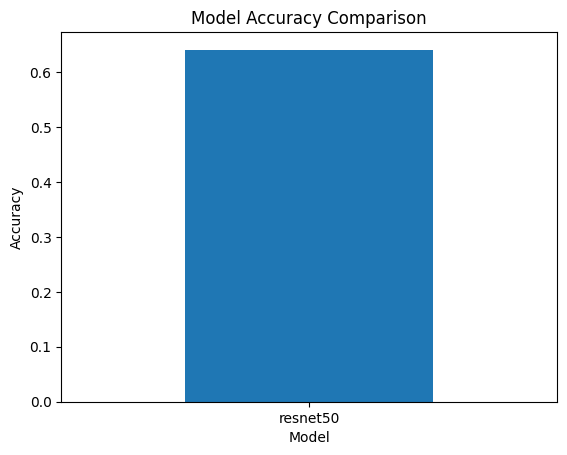

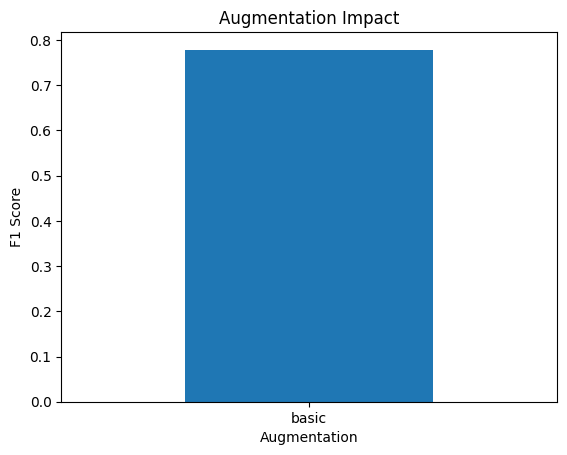


🏆 BEST MODEL:

Model           resnet50
Augmentation       basic
Accuracy          0.6406
Precision         0.6537
Recall            0.9619
F1 Score          0.7784
TP                   202
TN                     3
FP                   107
FN                     8
Name: 0, dtype: object


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.DataFrame(results)


df = df[
    ["Model","Augmentation","Accuracy","Precision","Recall","F1 Score","TP","TN","FP","FN"]
]

print("\nFINAL RESULTS TABLE:\n")
print(df)



df.to_csv("breakhis_results.csv", index=False)
print("\n File saved as breakhis_results.csv")





plt.figure()
df.groupby("Model")["Accuracy"].mean().plot(kind="bar")
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()



plt.figure()
df.groupby("Augmentation")["F1 Score"].mean().plot(kind="bar")
plt.title("Augmentation Impact")
plt.xlabel("Augmentation")
plt.ylabel("F1 Score")
plt.xticks(rotation=0)
plt.show()



best = df.sort_values(by="F1 Score", ascending=False).iloc[0]

print("\n🏆 BEST MODEL:\n")
print(best)

In [ ]:
results = []

print("Starting experiments (ALL MODELS)...")

for model_name, base_model in get_models().items():
    print("\nModel loaded:", model_name)


    aug_name = "basic"
    transform = augmentations[aug_name]

    print(f"Running {model_name} + {aug_name}")

    model = modify_model(base_model, model_name)

    train_loader, test_loader = get_loaders(transform)

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()


    model.train()
    for i, (x, y) in enumerate(train_loader):
        if i >= 5:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

    print("Quick training done")


    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for i, (x, y) in enumerate(test_loader):
            if i >= 5:
                break

            x = x.to(device)
            preds = torch.argmax(model(x), dim=1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(y.numpy())

    from sklearn.metrics import *

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "TP": tp, "TN": tn, "FP": fp, "FN": fn
    }

    print("Accuracy:", metrics["Accuracy"])

    results.append({
        "Model": model_name,
        "Augmentation": aug_name,
        "Accuracy": round(metrics["Accuracy"], 4),
        "Precision": round(metrics["Precision"], 4),
        "Recall": round(metrics["Recall"], 4),
        "F1 Score": round(metrics["F1"], 4),
        "TP": metrics["TP"],
        "TN": metrics["TN"],
        "FP": metrics["FP"],
        "FN": metrics["FN"]
    })

Starting experiments (ALL MODELS)...

Model loaded: resnet50
Running resnet50 + basic
Quick training done
Accuracy: 0.58125

Model loaded: densenet121
Running densenet121 + basic
Quick training done
Accuracy: 0.675

Model loaded: efficientnet_b0
Running efficientnet_b0 + basic
Quick training done
Accuracy: 0.54375

Model loaded: mobilenet_v2
Running mobilenet_v2 + basic
Quick training done
Accuracy: 0.5875

Model loaded: vgg16
Running vgg16 + basic
Quick training done
Accuracy: 0.68125

Model loaded: alexnet
Running alexnet + basic
Quick training done
Accuracy: 0.69375

Model loaded: resnext50
Running resnext50 + basic
Quick training done
Accuracy: 0.525

Model loaded: convnext_tiny
Running convnext_tiny + basic
Quick training done
Accuracy: 0.55625

Model loaded: shufflenet
Running shufflenet + basic
Quick training done
Accuracy: 0.34375


In [ ]:
print("\nFLIP AUGMENTATION")

for model_name, base_model in get_models().items():
    transform = augmentations["flip"]

    print(f"\nRunning {model_name} + flip")

    model = modify_model(base_model, model_name)
    train_loader, test_loader = get_loaders(transform)

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    for i, (x, y) in enumerate(train_loader):
        if i >= 5:
            break
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

    metrics = evaluate(model, test_loader)

    results.append({
        "Model": model_name,
        "Augmentation": "flip",
        **metrics
    })


FLIP AUGMENTATION

Running resnet50 + flip

Running densenet121 + flip

Running efficientnet_b0 + flip

Running mobilenet_v2 + flip

Running vgg16 + flip

Running alexnet + flip

Running resnext50 + flip


KeyboardInterrupt: 

In [ ]:
print("\nROTATION AUGMENTATION")

for model_name, base_model in get_models().items():
    transform = augmentations["rotation"]

    print(f"\nRunning {model_name} + rotation")

    model = modify_model(base_model, model_name)
    train_loader, test_loader = get_loaders(transform)

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    for i, (x, y) in enumerate(train_loader):
        if i >= 5:
            break
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

    metrics = evaluate(model, test_loader)

    results.append({
        "Model": model_name,
        "Augmentation": "rotation",
        **metrics
    })

In [ ]:
print("\n STRONG AUGMENTATION")

for model_name, base_model in get_models().items():
    transform = augmentations["strong"]

    print(f"\nRunning {model_name} + strong")

    model = modify_model(base_model, model_name)
    train_loader, test_loader = get_loaders(transform)

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    for i, (x, y) in enumerate(train_loader):
        if i >= 5:
            break
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

    metrics = evaluate(model, test_loader)

    results.append({
        "Model": model_name,
        "Augmentation": "strong",
        **metrics
    })

In [ ]:
import pandas as pd

df = pd.DataFrame(results)

df = df[[
    "Model","Augmentation","Accuracy","Precision","Recall","F1","TP","TN","FP","FN"
]]

print("\nFINAL COMBINED TABLE:\n")
print(df)


FINAL COMBINED TABLE:

              Model Augmentation  Accuracy  Precision    Recall        F1  \
0          resnet50        basic  0.581300   0.675000  0.743100       NaN   
1       densenet121        basic  0.675000   0.705000  0.899100       NaN   
2   efficientnet_b0        basic  0.543700   0.687500  0.605500       NaN   
3      mobilenet_v2        basic  0.587500   0.661700  0.807300       NaN   
4             vgg16        basic  0.681300   0.685900  0.981700       NaN   
5           alexnet        basic  0.693700   0.689900  1.000000       NaN   
6         resnext50        basic  0.525000   0.654200  0.642200       NaN   
7     convnext_tiny        basic  0.556300   0.779400  0.486200       NaN   
8        shufflenet        basic  0.343800   0.590900  0.119300       NaN   
9          resnet50         flip  0.662453   0.686486  0.935543  0.791894   
10      densenet121         flip  0.497472   0.711790  0.450276  0.551607   
11  efficientnet_b0         flip  0.498736   0.64843

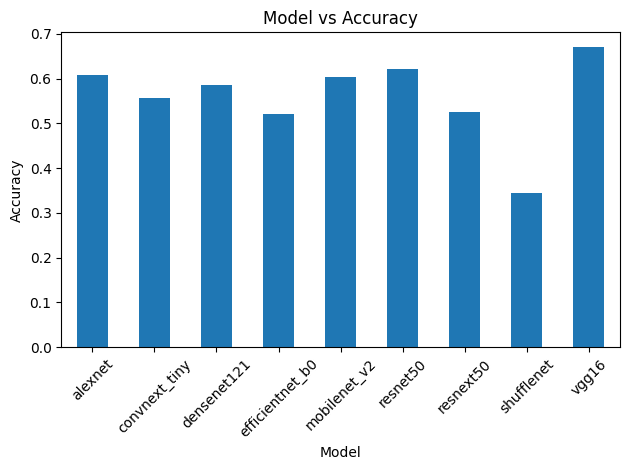

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
df.groupby("Model")["Accuracy"].mean().plot(kind="bar")
plt.title("Model vs Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

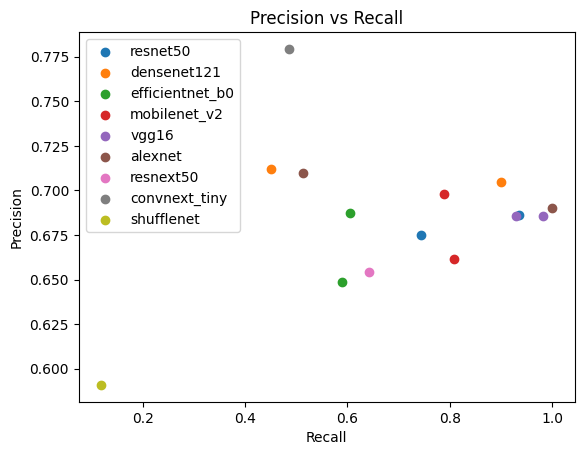

In [ ]:
plt.figure()

for model in df["Model"].unique():
    subset = df[df["Model"] == model]
    plt.scatter(subset["Recall"], subset["Precision"], label=model)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall")
plt.legend()
plt.show()

In [ ]:
best = df.sort_values(by="F1", ascending=False).iloc[0]

print("\nBEST CONFIGURATION:\n")
print(best)


BEST CONFIGURATION:

Model           resnet50
Augmentation        flip
Accuracy        0.662453
Precision       0.686486
Recall          0.935543
F1              0.791894
TP                  1016
TN                    32
FP                   464
FN                    70
Name: 9, dtype: object


In [42]:
import torch
import torch.nn.functional as F

# 1. Create and define the models_dict using your existing functions
print("Initializing models for ensemble...")
models_dict = {}
for model_name, base_model in get_models().items():
    # Modify each model for 2 classes and move to device
    models_dict[model_name] = modify_model(base_model, model_name)

# 2. Put the specific models you want to use into a list
ensemble_models = [
    models_dict['resnet50'],
    models_dict['vgg16'],
    models_dict['alexnet'],
    models_dict['densenet121'],
    models_dict['mobilenet_v2']
]

# 3. Defining the Ensemble Function
def ensemble_soft_voting(models_list, image_tensor):
    """
    Takes a list of PyTorch models and a single image tensor.
    Returns the final prediction (Benign or Malignant) based on Soft Voting.
    """
    # Ensuring all models are in evaluation mode
    for m in models_list:
        m.eval()

    total_probabilities = torch.zeros(1, 2).to(device) # Shape [1, 2] for 2 classes

    with torch.no_grad():
        for m in models_list:
            # Get raw output (logits) from the model
            outputs = m(image_tensor)

            # Convert raw output to probabilities using Softmax
            probabilities = F.softmax(outputs, dim=1)

            # Add to our running total
            total_probabilities += probabilities

    # Calculate the average probabilities across all models
    avg_probabilities = total_probabilities / len(models_list)

    # Find the class with the highest average probability
    predicted_class = torch.argmax(avg_probabilities, dim=1).item()

    # Get the confidence score for the prediction
    confidence = avg_probabilities[0][predicted_class].item() * 100

    return predicted_class, confidence

# Grabbing one batch of images from test loader ('basic' transform)
transform = augmentations["basic"]
_, test_loader = get_loaders(transform)
data_iter = iter(test_loader)
images, labels = next(data_iter)

# Moving ONE single image to the device
single_image = images[0].unsqueeze(0).to(device)

# Running the Ensemble
print("Running Ensemble Prediction...")
prediction, conf = ensemble_soft_voting(ensemble_models, single_image)

class_names = {0: "Benign", 1: "Malignant"}
print("-" * 30)
print(f"Ensemble Prediction: {class_names[prediction]} (Confidence: {conf:.2f}%)")
print(f"Actual Truth: {class_names[labels[0].item()]}")
print("-" * 30)

Initializing models for ensemble...
Running Ensemble Prediction...
------------------------------
Ensemble Prediction: Malignant (Confidence: 51.11%)
Actual Truth: Malignant
------------------------------
